In [1]:
using CSV
using DataFrames
include("config.jl")

df = CSV.read("../../results/liquidity_optimization/results.csv", DataFrame);

In [2]:
v_min_reserves_factor =  V_MIN_RESERVES_FACTOR
v_r_client_loan = V_R_CLIENT_LOAN 
v_r_deposit= V_R_DEPOSIT
v_r_bank_loan= V_R_BANK_LOAN;

In [3]:
using DataFrames

function add_derived_metrics!(df::DataFrame)
    df[!, :p_client_loans_granted] = df.n_client_loan_granted ./ df.n_client_loan_requests
    df[!, :p_defaulted_deposits] = df.n_defaulted_deposits ./ df.n_client_deposits
    df[!, :bank_net_growth_ratio] = df.total_final_banks_net ./ df.total_initial_banks_net
    df[!, :p_defaulted_interbank_loans] = df.n_defaulted_bank_loans ./ df.n_interbank_loans
    return df
end

add_derived_metrics!(df);

In [4]:
using StatsPlots

function plot_heatmap_grid(
    df::DataFrame,
    varying_fixed_col::Symbol,
    varying_fixed_values::Vector{Float64},
    fixed_col::Symbol,
    fixed_val::Float64,
    x_col::Symbol,
    y_col::Symbol,
    value_col::Symbol
)
    n = length(varying_fixed_values)
    ncols = min(n, 2)  # max 2 columns
    nrows = cld(n, ncols)

    plt = plot(layout=(nrows, ncols), size=(ncols * 500, nrows * 400))

    for (i, val) in enumerate(varying_fixed_values)
        filtered_df = filter(row -> row[fixed_col] == fixed_val && row[varying_fixed_col] == val, df)
        pivot = unstack(filtered_df, y_col, x_col, value_col)
        sort!(pivot, y_col)
        cols_sorted = sort!(names(pivot)[2:end])
        values = Matrix(pivot[:, cols_sorted])

        title_str = "$(value_col):\n$(varying_fixed_col)=$(round(val, digits=3)), $(fixed_col)=$(round(fixed_val, digits=3))"

        heatmap!(
            plt[i],
            cols_sorted,
            pivot[:, y_col],
            values,
            xlabel=string(x_col),
            ylabel=string(y_col),
            title=title_str,
            c=:viridis,
            framestyle=:box,
            colorbar=true,
            titlefontsize=10,
            guidefontsize=9,
            tickfontsize=8
        )
    end

    display(plt)
end

plot_heatmap_grid (generic function with 1 method)

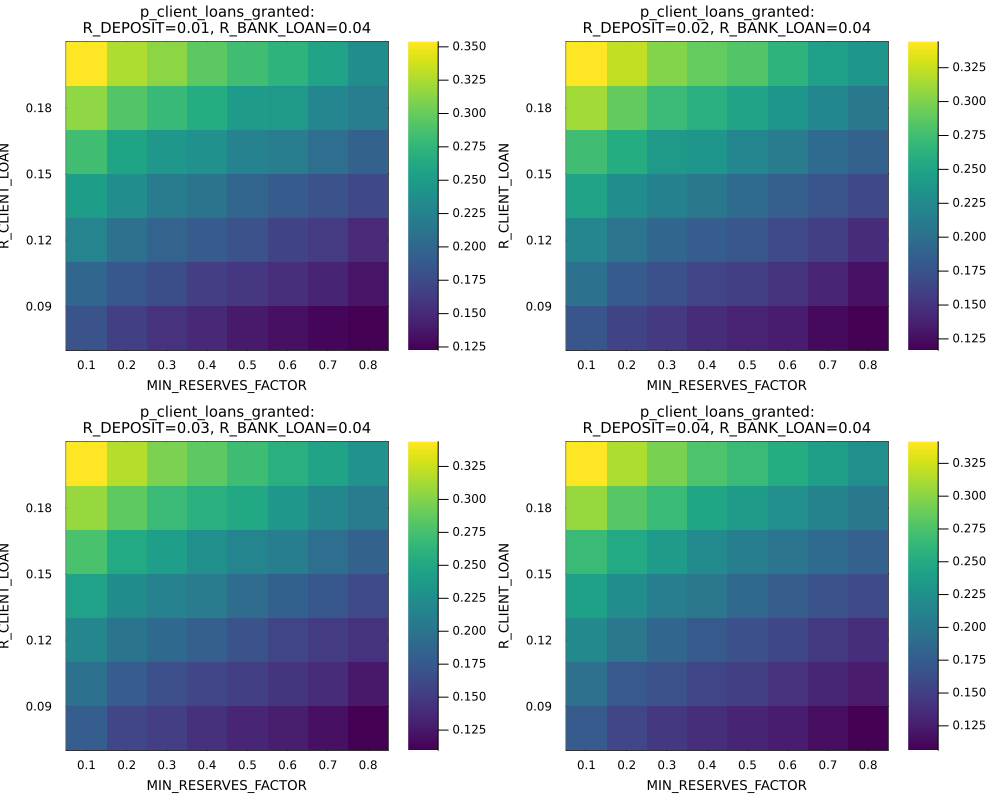

In [5]:
plot_heatmap_grid(
    df,
    :R_DEPOSIT,
    [0.01, 0.02, 0.03, 0.04],
    :R_BANK_LOAN,
    0.04,
    :MIN_RESERVES_FACTOR,
    :R_CLIENT_LOAN,
    :p_client_loans_granted
)

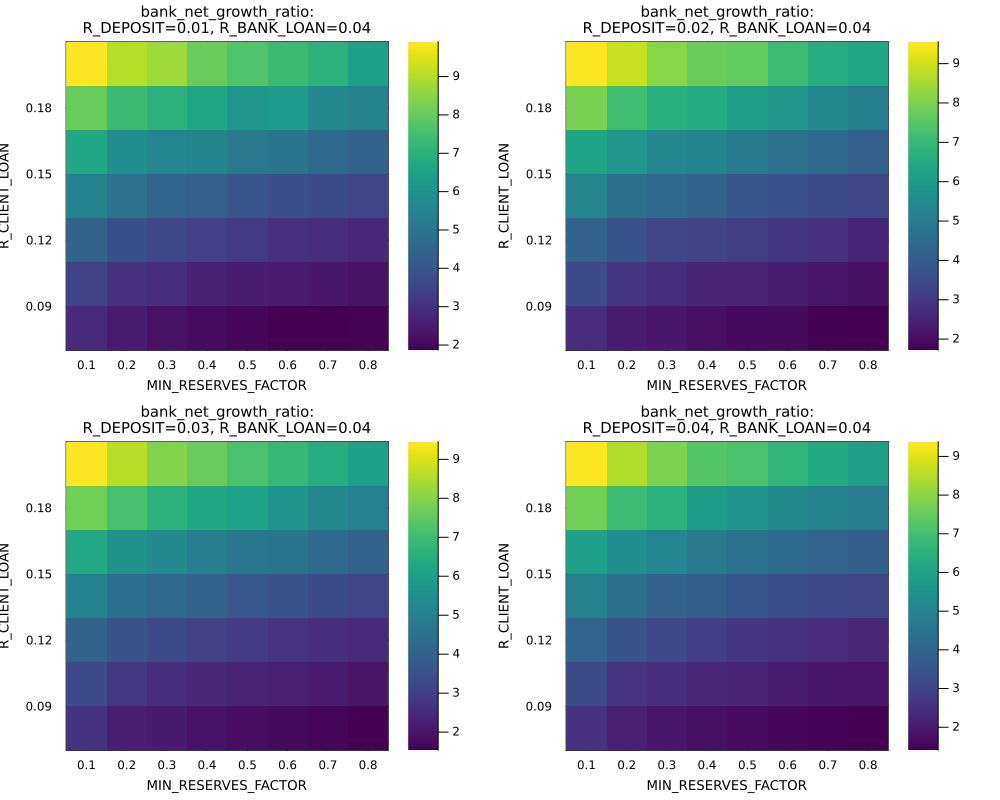

In [6]:
plot_heatmap_grid(
    df,
    :R_DEPOSIT,
    [0.01, 0.02, 0.03, 0.04],
    :R_BANK_LOAN,
    0.04,
    :MIN_RESERVES_FACTOR,
    :R_CLIENT_LOAN,
    :bank_net_growth_ratio
)

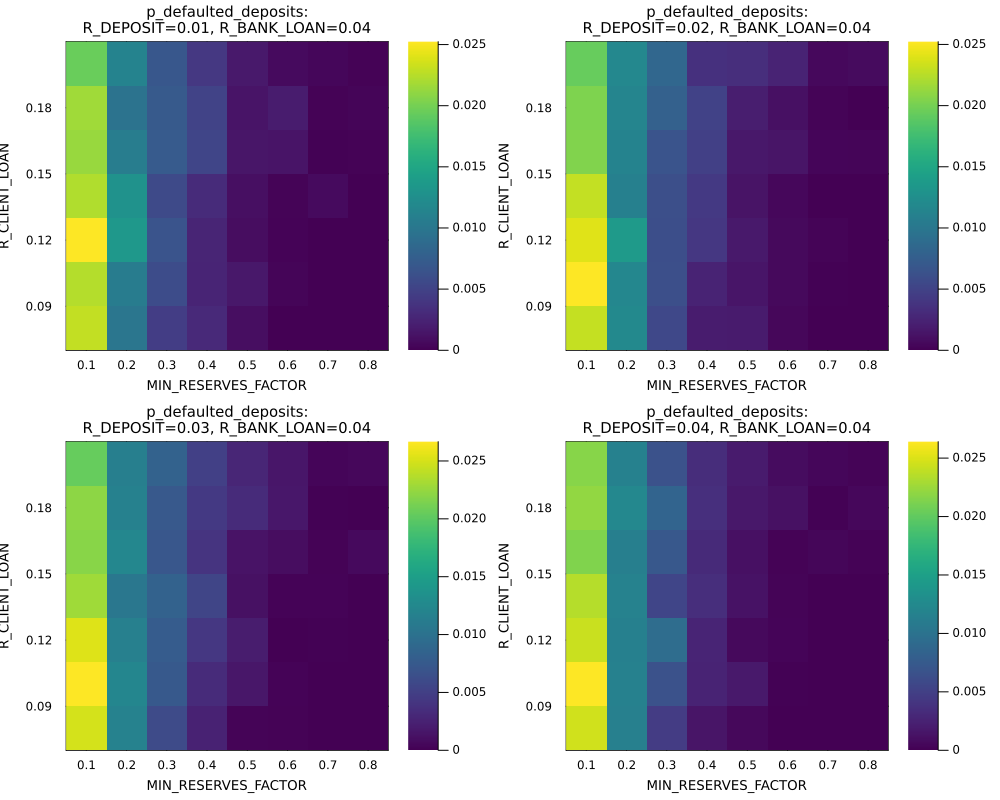

In [7]:
plot_heatmap_grid(
    df,
    :R_DEPOSIT,
    [0.01, 0.02, 0.03, 0.04],
    :R_BANK_LOAN,
    0.04,
    :MIN_RESERVES_FACTOR,
    :R_CLIENT_LOAN,
    :p_defaulted_deposits
)

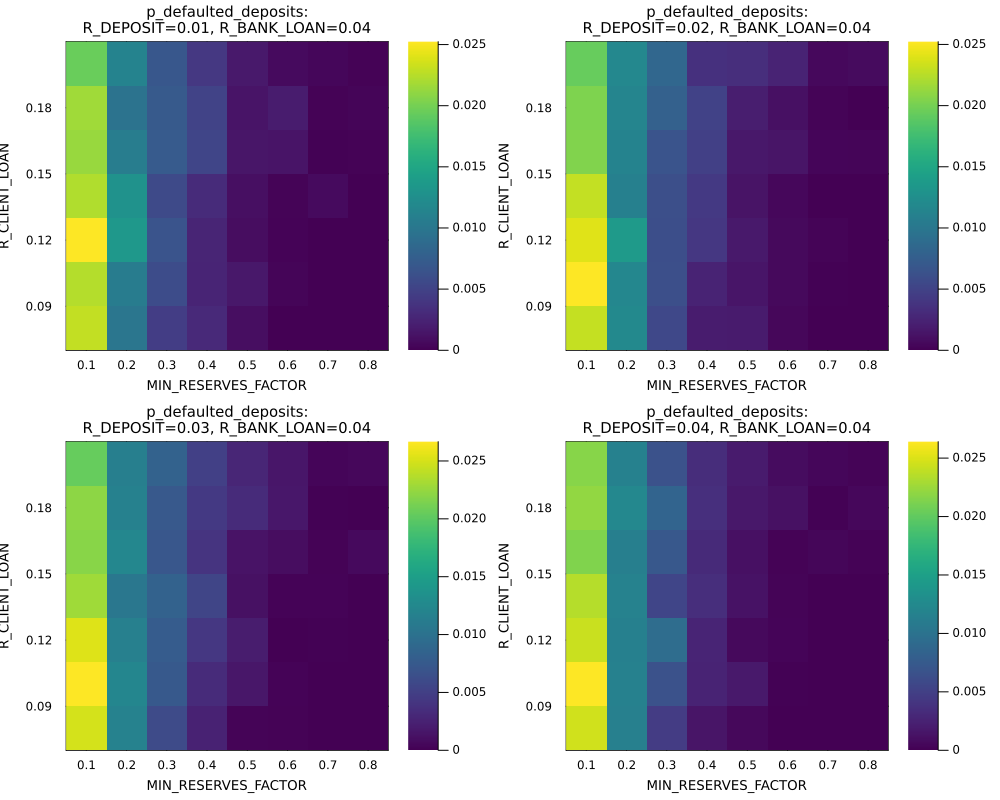

In [8]:
plot_heatmap_grid(
    df,
    :R_DEPOSIT,
    [0.01, 0.02, 0.03, 0.04],
    :R_BANK_LOAN,
    0.04,
    :MIN_RESERVES_FACTOR,
    :R_CLIENT_LOAN,
    :p_defaulted_deposits
)

## Designing a Composite Metric for Evaluating Banking System Parameters

To effectively evaluate different parameter settings in our agent-based banking simulation, we introduce a **composite metric** that captures the trade-offs and priorities of a stable and functional banking system. This metric is guided by the following assumptions and goals:

### Assumptions

1. **Sustainability of banks**  
   Banks must not operate at a long-term loss. If the banking system is unprofitable (i.e. total net assets shrink), it ceases to be viable.

2. **Client trust and stability**  
   Banks should fulfill their obligations to clients. A low `p_defaulted_deposits` (the proportion of client deposits that were defaulted on) is crucial.

3. **Access to credit**  
   A healthy economy benefits from easy access to credit. The higher the `p_client_loans_granted`, the better.

4. **Systemic trust and interbank reliability**  
   Defaults in the interbank market (`p_defaulted_interbank_loans`) weaken systemic trust and should be minimized.



### Metric Design

Let:
- `bank_net_growth_ratio` be the ratio of final to initial total net value of banks
- `p_client_loans_granted` be the fraction of client loan requests that were granted
- `p_defaulted_deposits` be the fraction of client deposits that were defaulted
- `p_defaulted_interbank_loans` be the fraction of interbank loans that were defaulted

We define the composite metric `SCORE` as:

```math
\text{SCORE} = 
\begin{cases}
0 & \text{if } \text{bank\_net\_growth\_ratio} \leq 1.0 \\
a_1 \cdot (1 - p_{\text{defaulted\_deposits}}) + 
a_2 \cdot p_{\text{client\_loans\_granted}} + 
a_3 \cdot (1 - p_{\text{defaulted\_interbank\_loans}}) & \text{otherwise}
\end{cases}

In [9]:
function add_score_column!(
    df::DataFrame;
    a1::Float64 = 1.0,
    a2::Float64 = 1.0,
    a3::Float64 = 1.0
)
    df.score = [
        row.bank_net_growth_ratio <= 0.0 ? 0.0 :
        a1 * (1.0 - row.:p_defaulted_deposits) +
        a2 * row.:p_client_loans_granted +
        a3 * (1.0 - row.:p_defaulted_interbank_loans)
        for row in eachrow(df)
    ]
    return df
end

add_score_column! (generic function with 1 method)

In [10]:
# Safety first parametes
a1 = 0.4
a2 = 0.1
a3 = 0.4 


df = add_score_column!(df, a1=a1, a2=a2, a3=a3);

In [11]:
function print_top_score_params(df::DataFrame, top_n::Int = 3)
    sorted_df = sort(df, :score, rev=true)
    println("Top $top_n parameter sets by score:\n")
    for i in 1:top_n
        row = sorted_df[i, :]
        println("Rank $i:")
        println("  score               = $(round(row.score, digits=4))")
        println("  MIN_RESERVES_FACTOR = $(row.MIN_RESERVES_FACTOR)")
        println("  R_CLIENT_LOAN       = $(row.R_CLIENT_LOAN)")
        println("  R_DEPOSIT           = $(row.R_DEPOSIT)")
        println("  R_BANK_LOAN         = $(row.R_BANK_LOAN)\n")
    end
end

print_top_score_params (generic function with 2 methods)

In [12]:
print_top_score_params(df)

Top 3 parameter sets by score:

Rank 1:
  score               = 0.8263
  MIN_RESERVES_FACTOR = 0.6
  R_CLIENT_LOAN       = 0.2
  R_DEPOSIT           = 0.01
  R_BANK_LOAN         = 0.05

Rank 2:
  score               = 0.8262
  MIN_RESERVES_FACTOR = 0.6
  R_CLIENT_LOAN       = 0.2
  R_DEPOSIT           = 0.01
  R_BANK_LOAN         = 0.04

Rank 3:
  score               = 0.8261
  MIN_RESERVES_FACTOR = 0.5
  R_CLIENT_LOAN       = 0.2
  R_DEPOSIT           = 0.01
  R_BANK_LOAN         = 0.07

